In [1]:
# Reproducible, Colab-safe setup
import importlib.util, subprocess, sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

required = {"mlxtend": "mlxtend", "wordcloud": "wordcloud", "psutil": "psutil"}
missing = [pkg for pkg, module in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="deep")
OUTPUT_DIR = Path("Output_Screenshots")
OUTPUT_DIR.mkdir(exist_ok=True)

def save_table_image(frame, filename, title, max_rows=12):
    shown = frame.head(max_rows).copy()
    fig_h = max(2.6, 0.38 * (len(shown) + 2))
    fig, ax = plt.subplots(figsize=(12, fig_h))
    ax.axis("off")
    ax.set_title(title, fontsize=15, fontweight="bold", pad=14)
    table = ax.table(cellText=shown.values, colLabels=shown.columns,
                     cellLoc="center", loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.35)
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor("#1f4e79")
            cell.set_text_props(color="white", weight="bold")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()

Dataset shape: (2800, 9) 
Fraud distribution:
 Fraud
0    2674
1     126
Name: count, dtype: int64


,Transaction_Amount,Transaction_Hour,Device_Risk,Location_Mismatch,Transaction_Frequency_24h,Account_Age_Days,Merchant_Risk,Failed_Login_Count,Fraud
0,90.442752,9,0.067602,1,2,925,0.375136,0,0
1,23.570971,9,0.308560,0,2,2348,0.339967,0,0
2,141.238676,20,0.112086,0,4,1075,0.149835,0,0
3,170.812202,2,0.096677,0,1,2443,0.108341,0,0
4,9.477919,20,0.441206,1,5,1527,0.317258,0,0


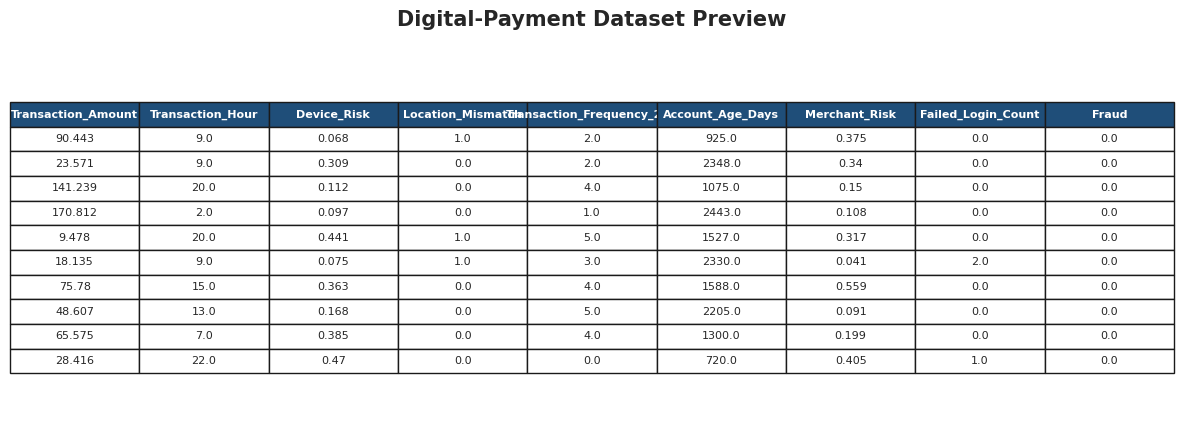

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import precision_score,recall_score,f1_score,confusion_matrix

n=2800
df=pd.DataFrame({"Transaction_Amount":rng.lognormal(4.2,1.0,n),"Transaction_Hour":rng.integers(0,24,n),
 "Device_Risk":rng.beta(2,8,n),"Location_Mismatch":rng.binomial(1,.08,n),"Transaction_Frequency_24h":rng.poisson(3,n),
 "Account_Age_Days":rng.integers(10,3000,n),"Merchant_Risk":rng.beta(2,7,n),"Failed_Login_Count":rng.poisson(.25,n)})
fraud_idx=rng.choice(n,size=int(.045*n),replace=False)
df["Fraud"]=0; df.loc[fraud_idx,"Fraud"]=1
df.loc[fraud_idx,"Transaction_Amount"]*=rng.uniform(5,12,len(fraud_idx))
df.loc[fraud_idx,"Device_Risk"]=rng.uniform(.7,1,len(fraud_idx)); df.loc[fraud_idx,"Location_Mismatch"]=1
df.loc[fraud_idx,"Transaction_Frequency_24h"]+=rng.integers(8,20,len(fraud_idx))
df.loc[fraud_idx,"Merchant_Risk"]=rng.uniform(.65,1,len(fraud_idx)); df.loc[fraud_idx,"Failed_Login_Count"]+=rng.integers(2,7,len(fraud_idx))
df.loc[rng.choice(n,15,replace=False),"Device_Risk"]=np.nan
print("Dataset shape:",df.shape,"\nFraud distribution:\n",df.Fraud.value_counts())
display(df.head()); save_table_image(df.head(10).round(3),"01_dataset_preview.png","Digital-Payment Dataset Preview")

In [3]:
X=df.drop(columns="Fraud").fillna(df.drop(columns="Fraud").median())
scaled=StandardScaler().fit_transform(X)
contamination=df.Fraud.mean()
iso=IsolationForest(n_estimators=350,contamination=contamination,random_state=SEED).fit(scaled)
iso_pred=(iso.predict(scaled)==-1).astype(int); df["Anomaly_Score"]=-iso.score_samples(scaled); df["IsolationForest_Flag"]=iso_pred
lof=LocalOutlierFactor(n_neighbors=35,contamination=contamination)
lof_pred=(lof.fit_predict(scaled)==-1).astype(int)
rows=[]
for name,pred in [("Isolation Forest",iso_pred),("Local Outlier Factor",lof_pred)]:
    rows.append([name,precision_score(df.Fraud,pred),recall_score(df.Fraud,pred),f1_score(df.Fraud,pred),int(pred.sum())])
scores=pd.DataFrame(rows,columns=["Model","Precision","Recall","F1","Flagged"])
display(scores.round(3)); print("Recall is crucial because missed fraud can cause direct financial loss and continued abuse.")

,Model,Precision,Recall,F1,Flagged
0,Isolation Forest,0.992,0.992,0.992,126
1,Local Outlier Factor,0.040,0.040,0.040,126


Recall is crucial because missed fraud can cause direct financial loss and continued abuse.


,Transaction_Amount,Transaction_Hour,Device_Risk,Location_Mismatch,Transaction_Frequency_24h,Account_Age_Days,Merchant_Risk,Failed_Login_Count,Fraud,Anomaly_Score,IsolationForest_Flag
2524,3741.487672,0,0.737680,1,24,182,0.951935,4,1,0.746844,1
57,2601.732766,14,0.880942,1,24,2975,0.689164,6,1,0.734866,1
2517,1855.962943,21,0.728464,1,21,22,0.855122,5,1,0.732230,1
1456,6107.016055,5,0.840793,1,21,793,0.796098,4,1,0.722334,1
1881,2238.281917,0,0.910538,1,21,1970,0.886824,4,1,0.717712,1
1148,2046.662237,10,0.774433,1,21,144,0.897118,4,1,0.717564,1
1914,1779.329847,10,0.763409,1,22,597,0.735874,6,1,0.716455,1
2338,2043.471751,5,0.991586,1,21,2044,0.869018,5,1,0.715573,1
2030,2530.282825,19,0.792148,1,16,2863,0.977664,5,1,0.715524,1
2627,2069.871950,23,0.775627,1,18,2541,0.920356,5,1,0.715000,1


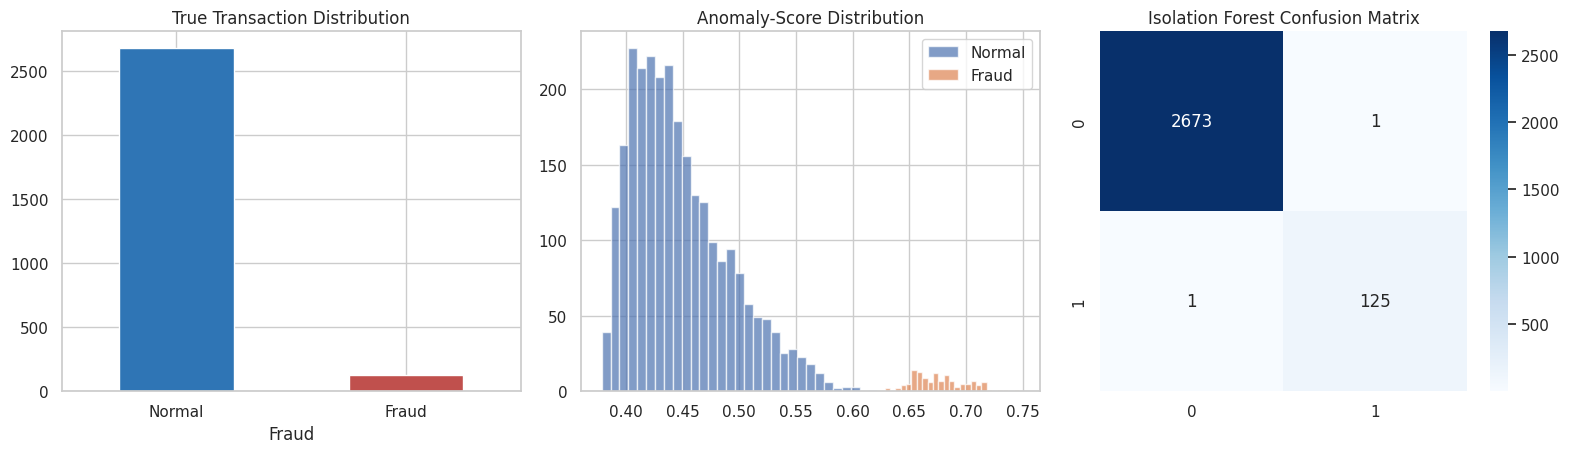

2292

In [4]:
suspicious=df.sort_values("Anomaly_Score",ascending=False).head(12)
display(suspicious)
fig,axes=plt.subplots(1,3,figsize=(16,4.7))
df.Fraud.value_counts().sort_index().plot.bar(ax=axes[0],color=["#2f75b5","#c0504d"]); axes[0].set_xticklabels(["Normal","Fraud"],rotation=0); axes[0].set_title("True Transaction Distribution")
axes[1].hist(df.loc[df.Fraud==0,"Anomaly_Score"],bins=35,alpha=.7,label="Normal"); axes[1].hist(df.loc[df.Fraud==1,"Anomaly_Score"],bins=25,alpha=.7,label="Fraud"); axes[1].legend(); axes[1].set_title("Anomaly-Score Distribution")
sns.heatmap(confusion_matrix(df.Fraud,iso_pred),annot=True,fmt="d",cmap="Blues",ax=axes[2]); axes[2].set_title("Isolation Forest Confusion Matrix")
fig.tight_layout(); fig.savefig(OUTPUT_DIR/"02_results.png",dpi=180,bbox_inches="tight"); plt.show()
metrics={"rows":len(df),"columns":9,"fraud_distribution":df.Fraud.value_counts().to_dict(),
         "scores":scores.round(4).to_dict("records"),"sample_suspicious":suspicious.head(5).round(3).to_dict("records"),
         "recall_note":"High recall reduces costly false negatives (missed fraud), balanced against investigation workload."}
Path("results.json").write_text(json.dumps(metrics,indent=2))